In [1]:
# /// script
# requires-python = ">=3.11"
# dependencies = [
#   "pandas",
#   "seaborn",
#   "matplotlib",
#   "pingouin",
# ]
# ///

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from scipy import stats
import numpy as np

In [3]:
d = pd.read_csv("MeanP2adaptersno9_long.csv")
d = d[d["Bin"] <= 6].copy()
d["Participant"] = d["Participant"].astype(str)
d["Bin"] = d["Bin"].astype(int)

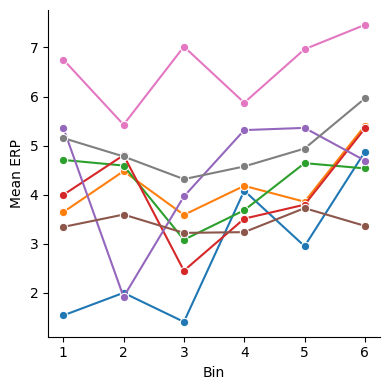

In [4]:
# Plot 1: individual participant trajectories
fig, ax = plt.subplots(figsize=(4, 4))
sns.lineplot(data=d, x="Bin", y="MeanERP", hue="Participant",
             marker="o", ax=ax, legend=False)
ax.set_xlabel("Bin")
ax.set_ylabel("Mean ERP")
sns.despine()
plt.tight_layout()
plt.show()

In [5]:
def cousineau_morey_ci(df, subject_col, condition_col, value_col, confidence=0.95):
    # 1. Calculate subject means and the grand mean
    subject_means = df.groupby(subject_col)[value_col].transform('mean')
    grand_mean = df[value_col].mean()
    
    # 2. Normalize: Subtract subject mean and add grand mean (Cousineau step)
    df['normalized_val'] = df[value_col] - subject_means + grand_mean
    
    # 3. Calculate number of conditions (c) and participants (n)
    c = df[condition_col].nunique()
    n = df[subject_col].nunique()
    
    # 4. Apply Morey's correction factor to the standard error
    # Correction factor = sqrt(c / (c - 1))
    correction_factor = np.sqrt(c / (c - 1))
    
    # 5. Compute mean and adjusted confidence interval per condition
    results = df.groupby(condition_col)['normalized_val'].agg(['mean', 'std']).reset_index()
    
    # Standard Error of the normalized data
    results['se'] = results['std'] / np.sqrt(n)
    
    # Adjust SE with Morey's factor
    results['se_adj'] = results['se'] * correction_factor
    
    # Calculate CI window using t-distribution
    t_val = stats.t.ppf((1 + confidence) / 2, n - 1)
    results['ci_half_width'] = t_val * results['se_adj']
    
    return results[[condition_col, 'mean', 'se_adj', 'ci_half_width']]

# Example usage:
# results = cousineau_morey_ci(my_data, 'Participant', 'Condition', 'ReactionTime')

   Bin      mean    se_adj  ci_half_width
0    1  4.313375  0.257541       0.608987
1    2  3.950250  0.418695       0.990057
2    3  3.632250  0.252375       0.596772
3    4  4.308000  0.276232       0.653185
4    5  4.530000  0.154390       0.365075
5    6  5.205750  0.266735       0.630729


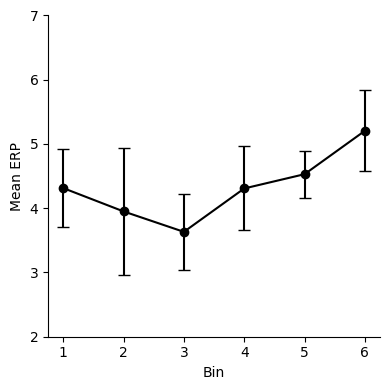

In [6]:
# Plot 2: group mean +/- 95% within-subject CI (Cousineau-Morey) with individual data in background

summary = cousineau_morey_ci(d, 'Participant', 'Bin', 'MeanERP')
print(summary)

fig, ax = plt.subplots(figsize=(4, 4))

ax.errorbar(summary["Bin"], summary["mean"],
            yerr=summary["ci_half_width"], fmt="o-", color="black",
            capsize=4, linewidth=1.5)

ax.set_xlabel("Bin")
ax.set_ylabel("Mean ERP")
ax.set_ylim([2,7])
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
# Repeated-measures ANOVA: MeanERP ~ Bin (within subjects)
aov = pg.rm_anova(data=d, dv="MeanERP", within="Bin", subject="Participant", detailed=True)
print(aov.to_string())

  Source         SS  DF        MS         F     p_unc       ng2       eps
0    Bin  11.507935   5  2.301587  3.621777  0.009586  0.133257  0.531346
1  Error  22.241994  35  0.635486       NaN       NaN       NaN       NaN


In [8]:
# Post-hoc pairwise paired t-tests with Holm correction
posthoc = pg.pairwise_tests(data=d, dv="MeanERP", within="Bin",
                             subject="Participant", padjust="holm")
print(posthoc[["A", "B", "T", "dof", "p_unc", "p_corr", "p_adjust"]].to_string())

    A  B         T  dof     p_unc    p_corr p_adjust
0   1  2  0.717031  7.0  0.496577  1.000000     holm
1   1  3  2.525102  7.0  0.039515  0.434662     holm
2   1  4  0.013304  7.0  0.989757  1.000000     holm
3   1  5 -1.164445  7.0  0.282390  1.000000     holm
4   1  6 -1.986760  7.0  0.087307  0.873073     holm
5   2  3  0.610070  7.0  0.561090  1.000000     holm
6   2  4 -0.634639  7.0  0.545839  1.000000     holm
7   2  5 -1.164874  7.0  0.282227  1.000000     holm
8   2  6 -2.958669  7.0  0.021145  0.253740     holm
9   3  4 -1.733273  7.0  0.126645  1.000000     holm
10  3  5 -3.992088  7.0  0.005242  0.078637     holm
11  3  6 -3.831994  7.0  0.006441  0.090175     holm
12  4  5 -0.882034  7.0  0.407025  1.000000     holm
13  4  6 -3.128248  7.0  0.016650  0.216456     holm
14  5  6 -1.949643  7.0  0.092216  0.873073     holm
